In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [2]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
from IPython.display import display

In [3]:
from sklearn.model_selection import RepeatedStratifiedKFold
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

In [4]:
X_train95 = pd.read_csv('./data/processed/X_train95.csv')
X_test95 = pd.read_csv('./data/processed/X_test95.csv')

X_train50 = pd.read_csv('./data/processed/X_train50.csv')
X_test50 = pd.read_csv('./data/processed/X_test50.csv')

X_train0 = pd.read_csv('./data/processed/X_train0.csv')
X_test0 = pd.read_csv('./data/processed/X_test0.csv')

X_train02 = pd.read_csv('./data/processed/X_train02.csv')
X_test02 = pd.read_csv('./data/processed/X_test02.csv')

Y_train = pd.read_csv('./data/processed/Y_train.csv').values.ravel()
Y_test = pd.read_csv('./data/processed/Y_test.csv').values.ravel()

print(X_train95.shape, X_train0.shape, Y_train.shape, X_test95.shape, X_train0.shape, Y_test.shape)

(2520, 74) (2520, 123) (2520,) (1080, 74) (2520, 123) (1080,)


In [5]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

def grid_search(estimator, param_grid, cv, scoring, X, Y, randomized=False, oversample=False):
    steps = []
    if oversample:
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('clf', estimator))

    pipe = ImbPipeline(steps)

    if isinstance(param_grid, list):
        pipe_param_grid = [{f'clf__{k}': v for k, v in grid.items()} for grid in param_grid]
    else:
        pipe_param_grid = {f'clf__{k}': v for k, v in param_grid.items()}

    if randomized:
        gs = RandomizedSearchCV(estimator=pipe, param_distributions=pipe_param_grid, n_iter=100, cv=cv, scoring=scoring, random_state=42, n_jobs=-1)
    else:
        gs = GridSearchCV(estimator=pipe, param_grid=pipe_param_grid, cv=cv, scoring=scoring)
    gs.fit(X, Y)

    print(f'Best params: {gs.best_params_}')
    print(f'F1 score: {gs.best_score_}')

    display(pd.DataFrame(gs.cv_results_)[['mean_test_score', 'params']].sort_values(by='mean_test_score', ascending=False).head(5))

    best_params = {k.replace('clf__', ''): v for k, v in gs.best_params_.items()}
    return best_params

In [6]:
def train_and_evaluate(classifier, best_params, X_train, Y_train, X_test, Y_test, oversample=False):
    smote = SMOTE(random_state=42)
    X_train_sm, Y_train_sm = smote.fit_resample(X_train, Y_train)

    model = classifier(**best_params)
    if oversample:
        model.fit(X_train_sm, Y_train_sm)
    else:
        model.fit(X_train, Y_train)

    preds = model.predict(X_test)

    print(f'Accuracy: {accuracy_score(Y_test, preds)}')
    print(f'F1 score: {f1_score(Y_test, preds)}')
    print(f'Precision: {precision_score(Y_test, preds)}')
    print(f'Recall: {recall_score(Y_test, preds)}')
    ConfusionMatrixDisplay.from_predictions(Y_test, preds)
    plt.show()

# **Ridge Classifier**

In [58]:
rgc_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000, 1500, 3000, 5000],
    'class_weight': [None, 'balanced'],
}

### PCA with 95% explainec variance

In [59]:
rgc95_best_params = grid_search(estimator=RidgeClassifier(), param_grid=rgc_params, cv=rskf, scoring='f1', X=X_train95, Y=Y_train)

Best params: {'clf__alpha': 1000, 'clf__class_weight': 'balanced'}
F1 score: 0.48908674016222453


,mean_test_score,params
13,0.489087,"{'clf__alpha': 1000, 'clf__class_weight': 'bal..."
15,0.486631,"{'clf__alpha': 1500, 'clf__class_weight': 'bal..."
17,0.482917,"{'clf__alpha': 3000, 'clf__class_weight': 'bal..."
19,0.482779,"{'clf__alpha': 5000, 'clf__class_weight': 'bal..."
11,0.481976,"{'clf__alpha': 100, 'clf__class_weight': 'bala..."


Accuracy: 0.7666666666666667
F1 score: 0.4793388429752066
Precision: 0.3483483483483483
Recall: 0.7682119205298014


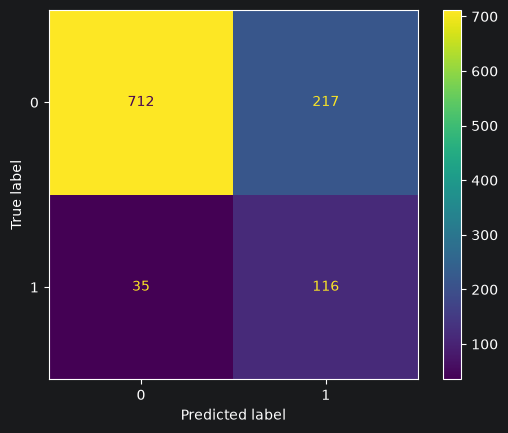

In [60]:
train_and_evaluate(classifier=RidgeClassifier, best_params=rgc95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

### Without PCA

In [49]:
rgc0_best_params = grid_search(estimator=RidgeClassifier(), param_grid=rgc_params, cv=rskf, scoring='f1', X=X_train0, Y=Y_train)

Best params: {'clf__alpha': 100, 'clf__class_weight': 'balanced'}
F1 score: 0.48726037692594865


,mean_test_score,params
11,0.487260,"{'clf__alpha': 100, 'clf__class_weight': 'bala..."
13,0.485721,"{'clf__alpha': 1000, 'clf__class_weight': 'bal..."
15,0.485168,"{'clf__alpha': 1500, 'clf__class_weight': 'bal..."
17,0.485165,"{'clf__alpha': 3000, 'clf__class_weight': 'bal..."
9,0.482456,"{'clf__alpha': 10, 'clf__class_weight': 'balan..."


Accuracy: 0.7787037037037037
F1 score: 0.48822269807280516
Precision: 0.36075949367088606
Recall: 0.7549668874172185


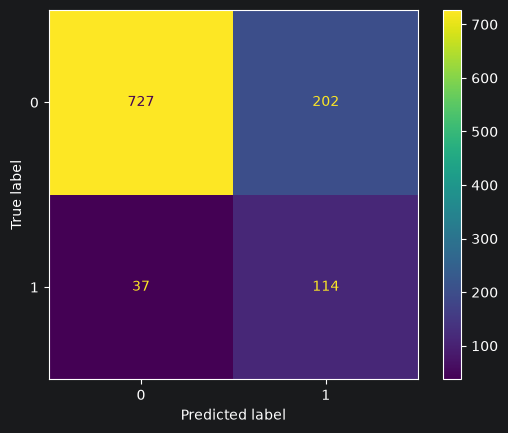

In [50]:
train_and_evaluate(classifier=RidgeClassifier, best_params=rgc0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [51]:
rgc50_best_params = grid_search(estimator=RidgeClassifier(), param_grid=rgc_params, cv=rskf, scoring='f1', X=X_train50, Y=Y_train)

Best params: {'clf__alpha': 1500, 'clf__class_weight': 'balanced'}
F1 score: 0.47267073376019064


,mean_test_score,params
15,0.472671,"{'clf__alpha': 1500, 'clf__class_weight': 'bal..."
13,0.471047,"{'clf__alpha': 1000, 'clf__class_weight': 'bal..."
17,0.470880,"{'clf__alpha': 3000, 'clf__class_weight': 'bal..."
19,0.470577,"{'clf__alpha': 5000, 'clf__class_weight': 'bal..."
11,0.470199,"{'clf__alpha': 100, 'clf__class_weight': 'bala..."


Accuracy: 0.7592592592592593
F1 score: 0.4715447154471545
Precision: 0.34017595307917886
Recall: 0.7682119205298014


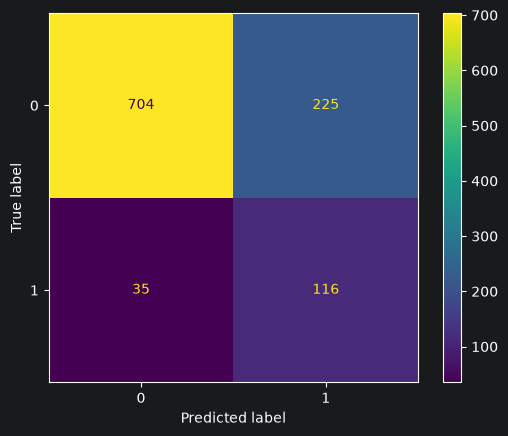

In [52]:
train_and_evaluate(classifier=RidgeClassifier, best_params=rgc50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# **LDA (Linear Discriminant Analysis)**

In [67]:
lda_params = [
    {
        'solver': ['svd'],
        'shrinkage': [None]
    },
    {
    'solver': ['lsqr', 'eigen'],
    'shrinkage': [None, 'auto', 0.1, 0.3, 0.6, 0.65, 0.67, 0.7, 0.72, 0.75]
    }
]

### PCA with 95% explained variance

In [68]:
lda95_best_params = grid_search(estimator=LinearDiscriminantAnalysis(), param_grid=lda_params, cv=rskf, scoring='f1', X=X_train95, Y=Y_train)

Best params: {'clf__shrinkage': 0.72, 'clf__solver': 'lsqr'}
F1 score: 0.4497612447752475


,mean_test_score,params
17,0.449761,"{'clf__shrinkage': 0.72, 'clf__solver': 'lsqr'}"
18,0.449761,"{'clf__shrinkage': 0.72, 'clf__solver': 'eigen'}"
15,0.449353,"{'clf__shrinkage': 0.7, 'clf__solver': 'lsqr'}"
16,0.449353,"{'clf__shrinkage': 0.7, 'clf__solver': 'eigen'}"
14,0.447563,"{'clf__shrinkage': 0.67, 'clf__solver': 'eigen'}"


Accuracy: 0.8611111111111112
F1 score: 0.4966442953020134
Precision: 0.5034013605442177
Recall: 0.4900662251655629


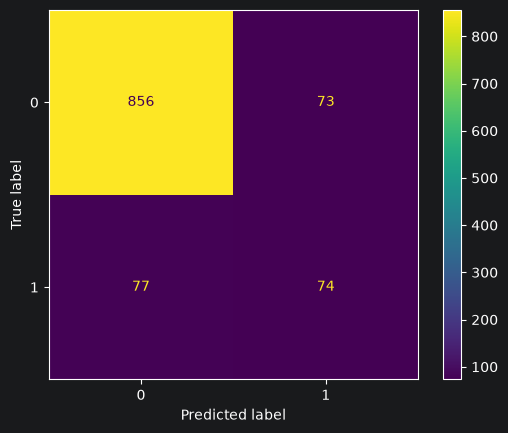

In [69]:
train_and_evaluate(classifier=LinearDiscriminantAnalysis, best_params=lda95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

### Without PCA

In [70]:
import warnings
from sklearn.exceptions import FitFailedWarning

warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# this is to get rid of warnings that occur when eigen solver cant fit all instances

In [71]:
lda0_best_params = grid_search(estimator=LinearDiscriminantAnalysis(), param_grid=lda_params, cv=rskf, scoring='f1', X=X_train0, Y=Y_train)

Best params: {'clf__shrinkage': 0.6, 'clf__solver': 'lsqr'}
F1 score: 0.46955288345662816


,mean_test_score,params
9,0.469553,"{'clf__shrinkage': 0.6, 'clf__solver': 'lsqr'}"
10,0.469553,"{'clf__shrinkage': 0.6, 'clf__solver': 'eigen'}"
11,0.469108,"{'clf__shrinkage': 0.65, 'clf__solver': 'lsqr'}"
12,0.469108,"{'clf__shrinkage': 0.65, 'clf__solver': 'eigen'}"
14,0.468487,"{'clf__shrinkage': 0.67, 'clf__solver': 'eigen'}"


Accuracy: 0.8648148148148148
F1 score: 0.5067567567567568
Precision: 0.5172413793103449
Recall: 0.4966887417218543


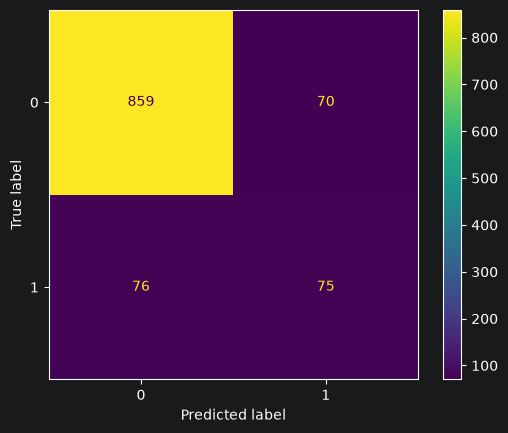

In [72]:
train_and_evaluate(classifier=LinearDiscriminantAnalysis, best_params=lda0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [73]:
lda50_best_params = grid_search(estimator=LinearDiscriminantAnalysis(), param_grid=lda_params, cv=rskf, scoring='f1', X=X_train50, Y=Y_train)

Best params: {'clf__shrinkage': 0.75, 'clf__solver': 'lsqr'}
F1 score: 0.42526899808006047


,mean_test_score,params
20,0.425269,"{'clf__shrinkage': 0.75, 'clf__solver': 'eigen'}"
19,0.425269,"{'clf__shrinkage': 0.75, 'clf__solver': 'lsqr'}"
18,0.424269,"{'clf__shrinkage': 0.72, 'clf__solver': 'eigen'}"
17,0.424269,"{'clf__shrinkage': 0.72, 'clf__solver': 'lsqr'}"
16,0.422326,"{'clf__shrinkage': 0.7, 'clf__solver': 'eigen'}"


Accuracy: 0.8601851851851852
F1 score: 0.4664310954063604
Precision: 0.5
Recall: 0.4370860927152318


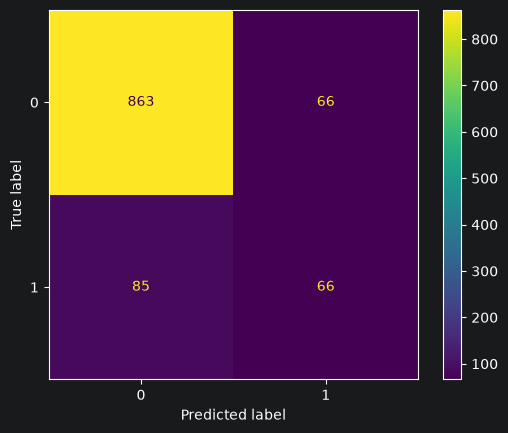

In [74]:
train_and_evaluate(classifier=LinearDiscriminantAnalysis, best_params=lda50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# Random Forest

In [22]:
from scipy.stats import randint

rf_params = {
    "n_estimators": [1000],
    "class_weight": ['balanced'],
    "max_depth": [None, 10, 15, 20, 30],
    "min_samples_split": randint(2, 50),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
    "criterion": ["gini", "entropy"]
}

# PCA with 95% explained variance

In [25]:
rf95_best_params = grid_search(estimator=RandomForestClassifier(), param_grid=rf_params, cv=5, scoring='f1', X=X_train95, Y=Y_train, randomized=True)

Best params: {'clf__bootstrap': True, 'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 34, 'clf__n_estimators': 1000}
F1 score: 0.47853646346209383


,mean_test_score,params
53,0.478536,"{'clf__bootstrap': True, 'clf__class_weight': ..."
87,0.476533,"{'clf__bootstrap': True, 'clf__class_weight': ..."
32,0.474862,"{'clf__bootstrap': True, 'clf__class_weight': ..."
64,0.473227,"{'clf__bootstrap': True, 'clf__class_weight': ..."
96,0.472231,"{'clf__bootstrap': True, 'clf__class_weight': ..."


Accuracy: 0.8175925925925925
F1 score: 0.47745358090185674
Precision: 0.39823008849557523
Recall: 0.5960264900662252


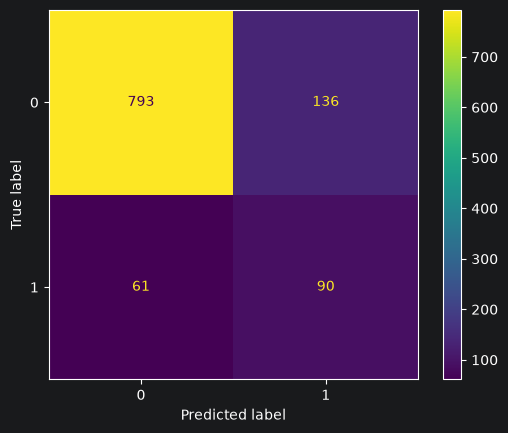

In [26]:
train_and_evaluate(classifier=RandomForestClassifier, best_params=rf95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

### Without PCA

In [27]:
rf0_best_params = grid_search(estimator=RandomForestClassifier(), param_grid=rf_params, cv=5, scoring='f1', X=X_train0, Y=Y_train, randomized=True)

Best params: {'clf__bootstrap': True, 'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 27, 'clf__n_estimators': 1000}
F1 score: 0.498917213536486


,mean_test_score,params
23,0.498917,"{'clf__bootstrap': True, 'clf__class_weight': ..."
76,0.497719,"{'clf__bootstrap': False, 'clf__class_weight':..."
14,0.497339,"{'clf__bootstrap': True, 'clf__class_weight': ..."
47,0.496756,"{'clf__bootstrap': True, 'clf__class_weight': ..."
10,0.496203,"{'clf__bootstrap': False, 'clf__class_weight':..."


Accuracy: 0.8185185185185185
F1 score: 0.49222797927461137
Precision: 0.40425531914893614
Recall: 0.6291390728476821


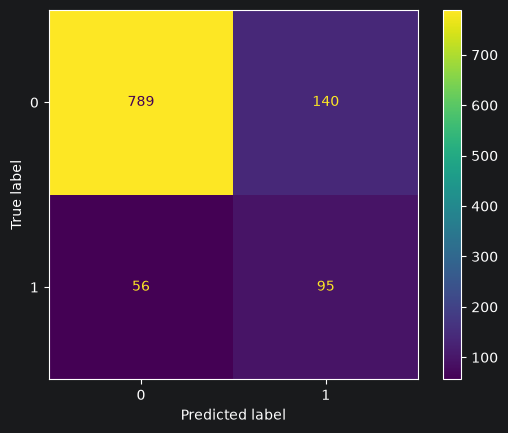

In [28]:
train_and_evaluate(classifier=RandomForestClassifier, best_params=rf0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [29]:
rf50_best_params = grid_search(estimator=RandomForestClassifier(), param_grid=rf_params, cv=5, scoring='f1', X=X_train50, Y=Y_train, randomized=True)

Best params: {'clf__bootstrap': False, 'clf__class_weight': 'balanced', 'clf__criterion': 'entropy', 'clf__max_depth': 30, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 18, 'clf__min_samples_split': 27, 'clf__n_estimators': 1000}
F1 score: 0.48243225715043775


,mean_test_score,params
12,0.482432,"{'clf__bootstrap': False, 'clf__class_weight':..."
29,0.480814,"{'clf__bootstrap': True, 'clf__class_weight': ..."
14,0.480798,"{'clf__bootstrap': True, 'clf__class_weight': ..."
38,0.480549,"{'clf__bootstrap': True, 'clf__class_weight': ..."
32,0.479360,"{'clf__bootstrap': True, 'clf__class_weight': ..."


Accuracy: 0.8305555555555556
F1 score: 0.48450704225352115
Precision: 0.4215686274509804
Recall: 0.5695364238410596


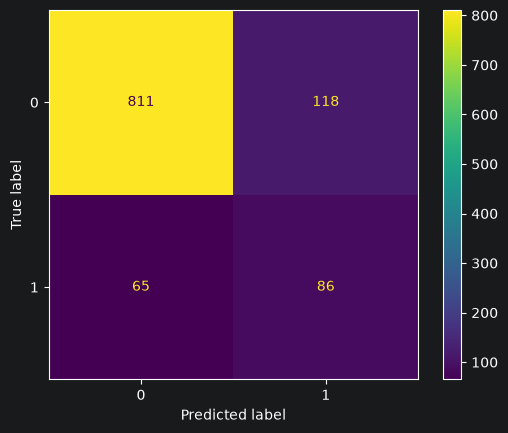

In [30]:
train_and_evaluate(classifier=RandomForestClassifier, best_params=rf50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# XGBoost

In [31]:
from sklearn.model_selection import train_test_split

class EarlyStoppingXGBClassifier(xgb.XGBClassifier):
    def fit(self, X, y, **kwargs):
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
        return super().fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

In [32]:
from scipy.stats import randint, uniform, loguniform

scale_pos_weight_ratio = (Y_train == 0).sum() / (Y_train == 1).sum()

xgb_params = {
    "n_estimators": [1000],
    "early_stopping_rounds": randint(10, 50),
    "max_depth": randint(3, 10),
    "learning_rate": loguniform(0.01, 0.3),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0, 5),
    "reg_alpha": loguniform(1e-3, 10),
    "reg_lambda": loguniform(1e-3, 10),
    "scale_pos_weight": uniform(scale_pos_weight_ratio * 0.5, scale_pos_weight_ratio * 1.0),
}

### PCA with 95% explained variance

In [33]:
xgb95_best_params = grid_search(estimator=EarlyStoppingXGBClassifier(), param_grid=xgb_params, cv=rskf, scoring='f1', X=X_train95, Y=Y_train, randomized=True)

Best params: {'clf__colsample_bytree': np.float64(0.9784778171526761), 'clf__early_stopping_rounds': 25, 'clf__gamma': np.float64(3.9480907139727694), 'clf__learning_rate': np.float64(0.013637114073970707), 'clf__max_depth': 4, 'clf__min_child_weight': 7, 'clf__n_estimators': 1000, 'clf__reg_alpha': np.float64(9.632188390621609), 'clf__reg_lambda': np.float64(0.001672956384704076), 'clf__scale_pos_weight': np.float64(7.6190144520537135), 'clf__subsample': np.float64(0.8183663080659955)}
F1 score: 0.4654511371987594


,mean_test_score,params
45,0.465451,"{'clf__colsample_bytree': 0.9784778171526761, ..."
72,0.464802,"{'clf__colsample_bytree': 0.9223459546964574, ..."
27,0.458630,"{'clf__colsample_bytree': 0.7222788077148727, ..."
99,0.457698,"{'clf__colsample_bytree': 0.6878042100323835, ..."
78,0.456092,"{'clf__colsample_bytree': 0.6265985069467109, ..."


Accuracy: 0.8018518518518518
F1 score: 0.46766169154228854
Precision: 0.3745019920318725
Recall: 0.6225165562913907


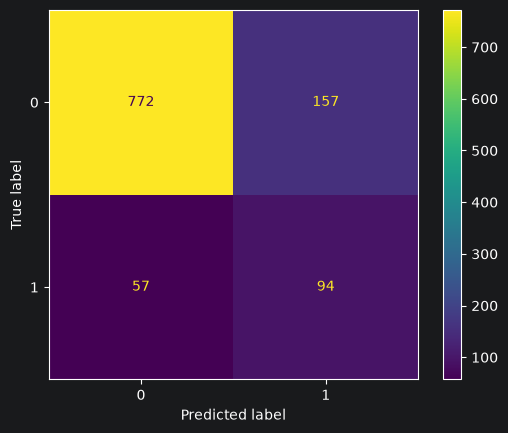

In [34]:
train_and_evaluate(classifier=EarlyStoppingXGBClassifier, best_params=xgb95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test)

In [35]:
xgb0_best_params = grid_search(estimator=EarlyStoppingXGBClassifier(), param_grid=xgb_params, cv=rskf, scoring='f1', X=X_train0, Y=Y_train, randomized=True)

Best params: {'clf__colsample_bytree': np.float64(0.9784778171526761), 'clf__early_stopping_rounds': 25, 'clf__gamma': np.float64(3.9480907139727694), 'clf__learning_rate': np.float64(0.013637114073970707), 'clf__max_depth': 4, 'clf__min_child_weight': 7, 'clf__n_estimators': 1000, 'clf__reg_alpha': np.float64(9.632188390621609), 'clf__reg_lambda': np.float64(0.001672956384704076), 'clf__scale_pos_weight': np.float64(7.6190144520537135), 'clf__subsample': np.float64(0.8183663080659955)}
F1 score: 0.5028885048640368


,mean_test_score,params
45,0.502889,"{'clf__colsample_bytree': 0.9784778171526761, ..."
70,0.502158,"{'clf__colsample_bytree': 0.823096906380175, '..."
7,0.500863,"{'clf__colsample_bytree': 0.718509402281633, '..."
16,0.499162,"{'clf__colsample_bytree': 0.8123738333268545, ..."
72,0.498766,"{'clf__colsample_bytree': 0.9223459546964574, ..."


Accuracy: 0.8203703703703704
F1 score: 0.5174129353233831
Precision: 0.41434262948207173
Recall: 0.6887417218543046


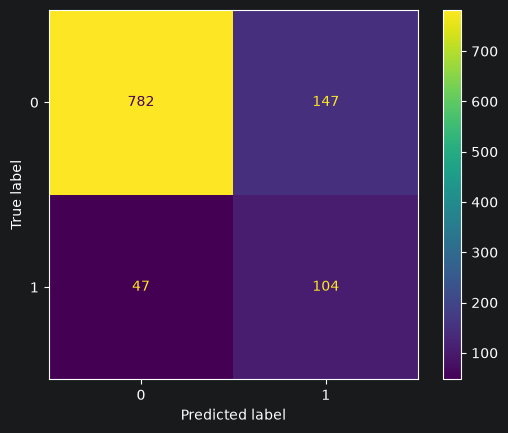

In [36]:
train_and_evaluate(classifier=EarlyStoppingXGBClassifier, best_params=xgb0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test)

### PCA with 50 components

In [37]:
xgb50_best_params = grid_search(estimator=EarlyStoppingXGBClassifier(), param_grid=xgb_params, cv=rskf, scoring='f1', X=X_train50, Y=Y_train, randomized=True)

Best params: {'clf__colsample_bytree': np.float64(0.9223459546964574), 'clf__early_stopping_rounds': 33, 'clf__gamma': np.float64(4.483827123132126), 'clf__learning_rate': np.float64(0.013137567821944727), 'clf__max_depth': 5, 'clf__min_child_weight': 8, 'clf__n_estimators': 1000, 'clf__reg_alpha': np.float64(0.6135441922383201), 'clf__reg_lambda': np.float64(9.750393411292787), 'clf__scale_pos_weight': np.float64(8.601849574226355), 'clf__subsample': np.float64(0.830399367122264)}
F1 score: 0.46592940127426485


,mean_test_score,params
72,0.465929,"{'clf__colsample_bytree': 0.9223459546964574, ..."
45,0.464025,"{'clf__colsample_bytree': 0.9784778171526761, ..."
7,0.463126,"{'clf__colsample_bytree': 0.718509402281633, '..."
36,0.456076,"{'clf__colsample_bytree': 0.616291520927588, '..."
16,0.455988,"{'clf__colsample_bytree': 0.8123738333268545, ..."


Accuracy: 0.825
F1 score: 0.4932975871313673
Precision: 0.4144144144144144
Recall: 0.609271523178808


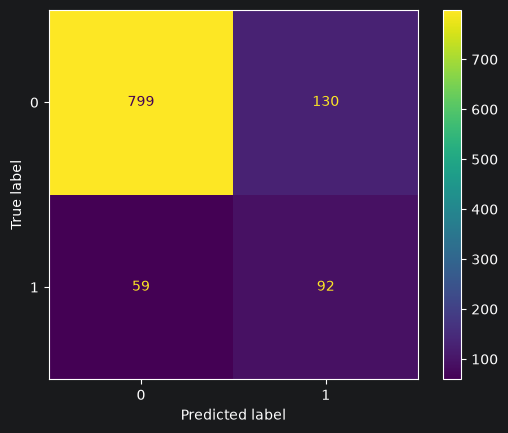

In [38]:
train_and_evaluate(classifier=EarlyStoppingXGBClassifier, best_params=xgb50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test)

# MLP (Multilayer Perceptron)

In [39]:
mlp_params = {
    "hidden_layer_sizes": [(16,), (32,), (64,), (128,), (32,16), (64,32), (128,64), (64,32,16), (128,64,32), (256, 128, 64), (512, 256, 128, 64), (256, 128, 64, 32), (128, 64, 32, 16)],
    "activation": ["relu", "tanh", "logistic"],
    "solver": ["adam"],
    "learning_rate_init": [0.001, 0.005, 0.01, 0.05, 0.1],
    "alpha": [0.000001, 0.00001, 0.0001, 0.001, 0.01],
    "batch_size": [32, 64, 128, 256, 512, 1024],
    "learning_rate": ["adaptive"],
    "max_iter": [2000],
    "early_stopping": [True],
    "validation_fraction": [0.2],
    "n_iter_no_change": [5, 10, 20]
}

### PCA with 95% explained variance

In [40]:
mlp95_best_params = grid_search(estimator=MLPClassifier(), param_grid=mlp_params, cv=rskf, scoring='f1', X=X_train95, Y=Y_train, randomized=True, oversample=True)

Best params: {'clf__validation_fraction': 0.2, 'clf__solver': 'adam', 'clf__n_iter_no_change': 5, 'clf__max_iter': 2000, 'clf__learning_rate_init': 0.001, 'clf__learning_rate': 'adaptive', 'clf__hidden_layer_sizes': (128,), 'clf__early_stopping': True, 'clf__batch_size': 128, 'clf__alpha': 0.01, 'clf__activation': 'tanh'}
F1 score: 0.4631827042693562


,mean_test_score,params
90,0.463183,"{'clf__validation_fraction': 0.2, 'clf__solver..."
70,0.461829,"{'clf__validation_fraction': 0.2, 'clf__solver..."
34,0.459900,"{'clf__validation_fraction': 0.2, 'clf__solver..."
9,0.457024,"{'clf__validation_fraction': 0.2, 'clf__solver..."
0,0.454210,"{'clf__validation_fraction': 0.2, 'clf__solver..."


Accuracy: 0.8333333333333334
F1 score: 0.48863636363636365
Precision: 0.42786069651741293
Recall: 0.5695364238410596


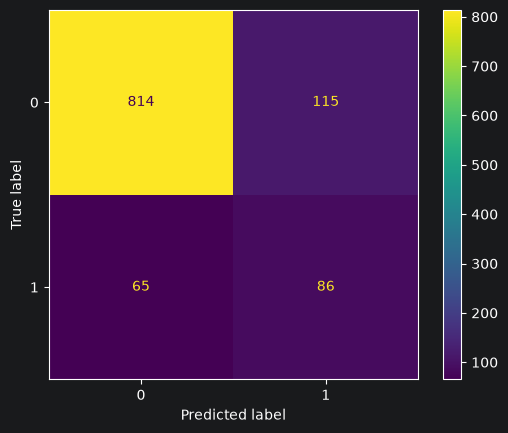

In [41]:
train_and_evaluate(classifier=MLPClassifier, best_params=mlp95_best_params, X_train=X_train95, Y_train=Y_train, X_test=X_test95, Y_test=Y_test, oversample=True)

### Without PCA

In [42]:
mlp0_best_params = grid_search(estimator=MLPClassifier(), param_grid=mlp_params, cv=rskf, scoring='f1', X=X_train0, Y=Y_train, randomized=True, oversample=True)

Best params: {'clf__validation_fraction': 0.2, 'clf__solver': 'adam', 'clf__n_iter_no_change': 5, 'clf__max_iter': 2000, 'clf__learning_rate_init': 0.001, 'clf__learning_rate': 'adaptive', 'clf__hidden_layer_sizes': (128,), 'clf__early_stopping': True, 'clf__batch_size': 128, 'clf__alpha': 0.01, 'clf__activation': 'tanh'}
F1 score: 0.460590983924057


,mean_test_score,params
90,0.460591,"{'clf__validation_fraction': 0.2, 'clf__solver..."
0,0.458214,"{'clf__validation_fraction': 0.2, 'clf__solver..."
70,0.450024,"{'clf__validation_fraction': 0.2, 'clf__solver..."
34,0.445404,"{'clf__validation_fraction': 0.2, 'clf__solver..."
31,0.442370,"{'clf__validation_fraction': 0.2, 'clf__solver..."


Accuracy: 0.8277777777777777
F1 score: 0.4918032786885246
Precision: 0.4186046511627907
Recall: 0.5960264900662252


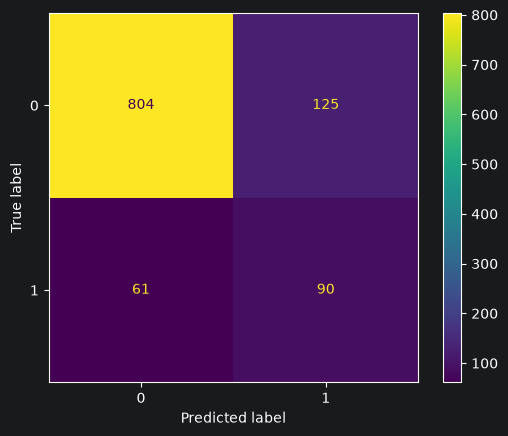

In [43]:
train_and_evaluate(classifier=MLPClassifier, best_params=mlp0_best_params, X_train=X_train0, Y_train=Y_train, X_test=X_test0, Y_test=Y_test, oversample=True)

### PCA with 50 components

In [44]:
mlp50_best_params = grid_search(estimator=MLPClassifier(), param_grid=mlp_params, cv=rskf, scoring='f1', X=X_train50, Y=Y_train, randomized=True, oversample=True)

Best params: {'clf__validation_fraction': 0.2, 'clf__solver': 'adam', 'clf__n_iter_no_change': 5, 'clf__max_iter': 2000, 'clf__learning_rate_init': 0.005, 'clf__learning_rate': 'adaptive', 'clf__hidden_layer_sizes': (128,), 'clf__early_stopping': True, 'clf__batch_size': 1024, 'clf__alpha': 1e-06, 'clf__activation': 'tanh'}
F1 score: 0.4574076860066617


,mean_test_score,params
53,0.457408,"{'clf__validation_fraction': 0.2, 'clf__solver..."
46,0.454945,"{'clf__validation_fraction': 0.2, 'clf__solver..."
9,0.445383,"{'clf__validation_fraction': 0.2, 'clf__solver..."
0,0.445273,"{'clf__validation_fraction': 0.2, 'clf__solver..."
90,0.444662,"{'clf__validation_fraction': 0.2, 'clf__solver..."


Accuracy: 0.8194444444444444
F1 score: 0.42136498516320475
Precision: 0.3817204301075269
Recall: 0.47019867549668876


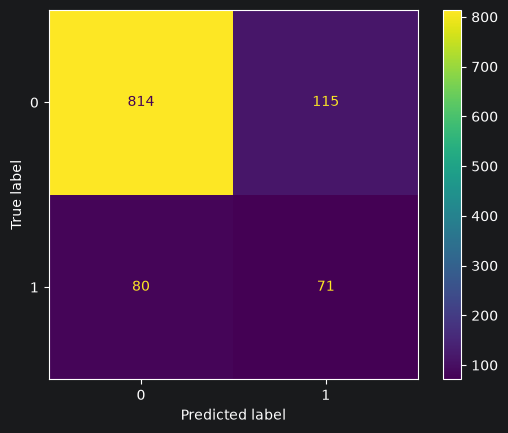

In [45]:
train_and_evaluate(classifier=MLPClassifier, best_params=mlp50_best_params, X_train=X_train50, Y_train=Y_train, X_test=X_test50, Y_test=Y_test, oversample=True)